In [1]:
import netCDF4 as nc
import matplotlib.pyplot as plt
from matplotlib.colors import from_levels_and_colors
import numpy as np
from matplotlib import animation
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as cols
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
from matplotlib import ticker, cm
import seaborn as sns
import xarray as xr

In [2]:
WMT2050mea = np.load("D:\\ihespdata\\WMT2050-2060mea.npy")

WMT2060mea = np.load("D:\\ihespdata\\WMT2060-2070mea.npy")

WMT2010mea = np.load("D:\\ihespdata\\WMT2010-2020mea.npy")

WMT2020mea = np.load("D:\\ihespdata\\WMT2020-2030mea.npy")

WMT2030mea1 = np.load("D:\\ihespdata\\WMT2030-2040mea1.npy")
WMT2030mea2 = np.load("D:\\ihespdata\\WMT2030-2040mea2.npy")
WMT2030mea = (WMT2030mea1 + WMT2030mea2)/2

WMT2040mea = np.load("D:\\ihespdata\\WMT2040-2050mea.npy")

data=nc.Dataset("D:\\ihespdata\\SDENFPI1000\\B.E.13.BRCP85C5CN.ne120_t12.sehires38.003.sunway.CN_OFF.pop.h.2063-04.SDEN_F.nc")
data

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): time(1), nlat(2400), nlon(3600), qcomp(9), fcomp(7)
    variables(dimensions): float64 time(time), float64 TLAT(nlat, nlon), float64 TLONG(nlat, nlon), float32 SDEN_F(time, nlat, nlon), <class 'str'> qcomp(qcomp), float32 SDEN_F_Q(time, qcomp, nlat, nlon), <class 'str'> fcomp(fcomp), float32 SDEN_F_F(time, fcomp, nlat, nlon), float64 sigma0(time, nlat, nlon), float64 sigma1(time, nlat, nlon), float64 TAREA(nlat, nlon)
    groups: 

In [3]:
data222=nc.Dataset("D:\\ihespdata\\B.E.13.BRCP85C5CN.ne120_t12.sehires38.003.sunway.CN_OFF.pop.h.nday1.2090-09-01.mon.nc")

HT = data222.variables['HT'][:,:]/100 

rmask = data222.variables['REGION_MASK'][:,:]

In [4]:
#sigma1 = data.variables['sigma1'][0,:,:]
qcomp = data.variables['qcomp']
sigma0 = data.variables['sigma0'][0,:,:]
TAREA = data.variables['TAREA']

TLAT = data.variables['TLAT'][:,:]
TLONG = data.variables['TLONG'][:,:]

In [5]:
lont = TLONG
latt = TLAT

lont = lont[:601,:]
latt = latt[:601,:]
lont2 = lont[50:320,800]
latt2 = latt[50:320,800]

#lont2 = lont[50:100,800]
#latt2 = latt[50:100,800]

##lont3 = lont[140:320,300]
#latt3 = latt[140:320,300]

lont3 = lont[140:150,300]
latt3 = latt[140:150,300]

#lont7 = lont[140:320,-100]
#latt7 = latt[140:320,-100]

lont7 = lont[140:150,-100]
latt7 = latt[140:150,-100]

#lont8 = lont[320,0:300]
#latt8 = latt[320,0:300]

lont8 = lont[150,0:300]
latt8 = latt[150,0:300]

lont9 = lont[320,3500:3600]
latt9 = latt[320,3500:3600]

lont4 = lont[220:320,2720]
latt4 = latt[220:320,2720]
lont10 = lont[20:320,3100]
latt10 = latt[20:320,3100]
lont12 = lont[320,2720:3100]
latt12 = latt[320,2720:3100]
######################################## box region
lont11 = lont[290:380,2500]
latt11 = latt[290:380,2500]
lont13 = lont[250:380,2700]
latt13 = latt[250:380,2700]
lont14 = lont[380,2500:2700]
latt14 = latt[380,2500:2700]
########################### section 67.5
#lont5 = lont[259,500:650]
#latt5 = latt[259,500:650]
########################### section 70
lont5 = lont[190,500:650]
latt5 = latt[190,500:650]
#########################
lont6 = lont[320,530:800]
latt6 = latt[320,530:800]

# = lont[190,500:550]
#latt6 = latt[190,500:550]
############################## box region 1
lont15 = lont[265:350,1750]
latt15 = latt[265:350,1750]
lont16 = lont[240:350,1860]
latt16 = latt[240:350,1860]
lont17 = lont[350,1750:1860]
latt17 = latt[350,1750:1860]
###############################

lontsec1 = lont[300:440,2233]
lattsec1 = latt[300:440,2233]

##############################
lontsec2 = lont[60:300,2820]
lattsec2 = latt[60:300,2820]

TLONG[TLONG==-1]=np.nan
TLAT[TLAT==-1]=np.nan

In [6]:
nice_cmap=plt.get_cmap('Reds')
lev_cmap = nice_cmap([0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,\
                      200,210,220,230,240])
new_cmap = cols.ListedColormap(lev_cmap,"Reds")
nice_levels = [0,0.2,0.4,0.6,0.8,1,1.2,1.4,1.6,1.8,2,2.2,2.4,2.6,2.8,3,3.2,3.4,3.6,3.8,4]
nice_levels = [-5,-4,-3,-2,-1,0,1,2,3,4,5]
nice_levels = [0,1,2,3,4,5]
#nice_levels = [34.5,34.52,34.54,34.56,34.58,34.6,34.62,34.64,34.66,34.68,34.7,34.72,34.74,34.76,34.78,34.8,34.82,34.84,34.86,34.88]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)

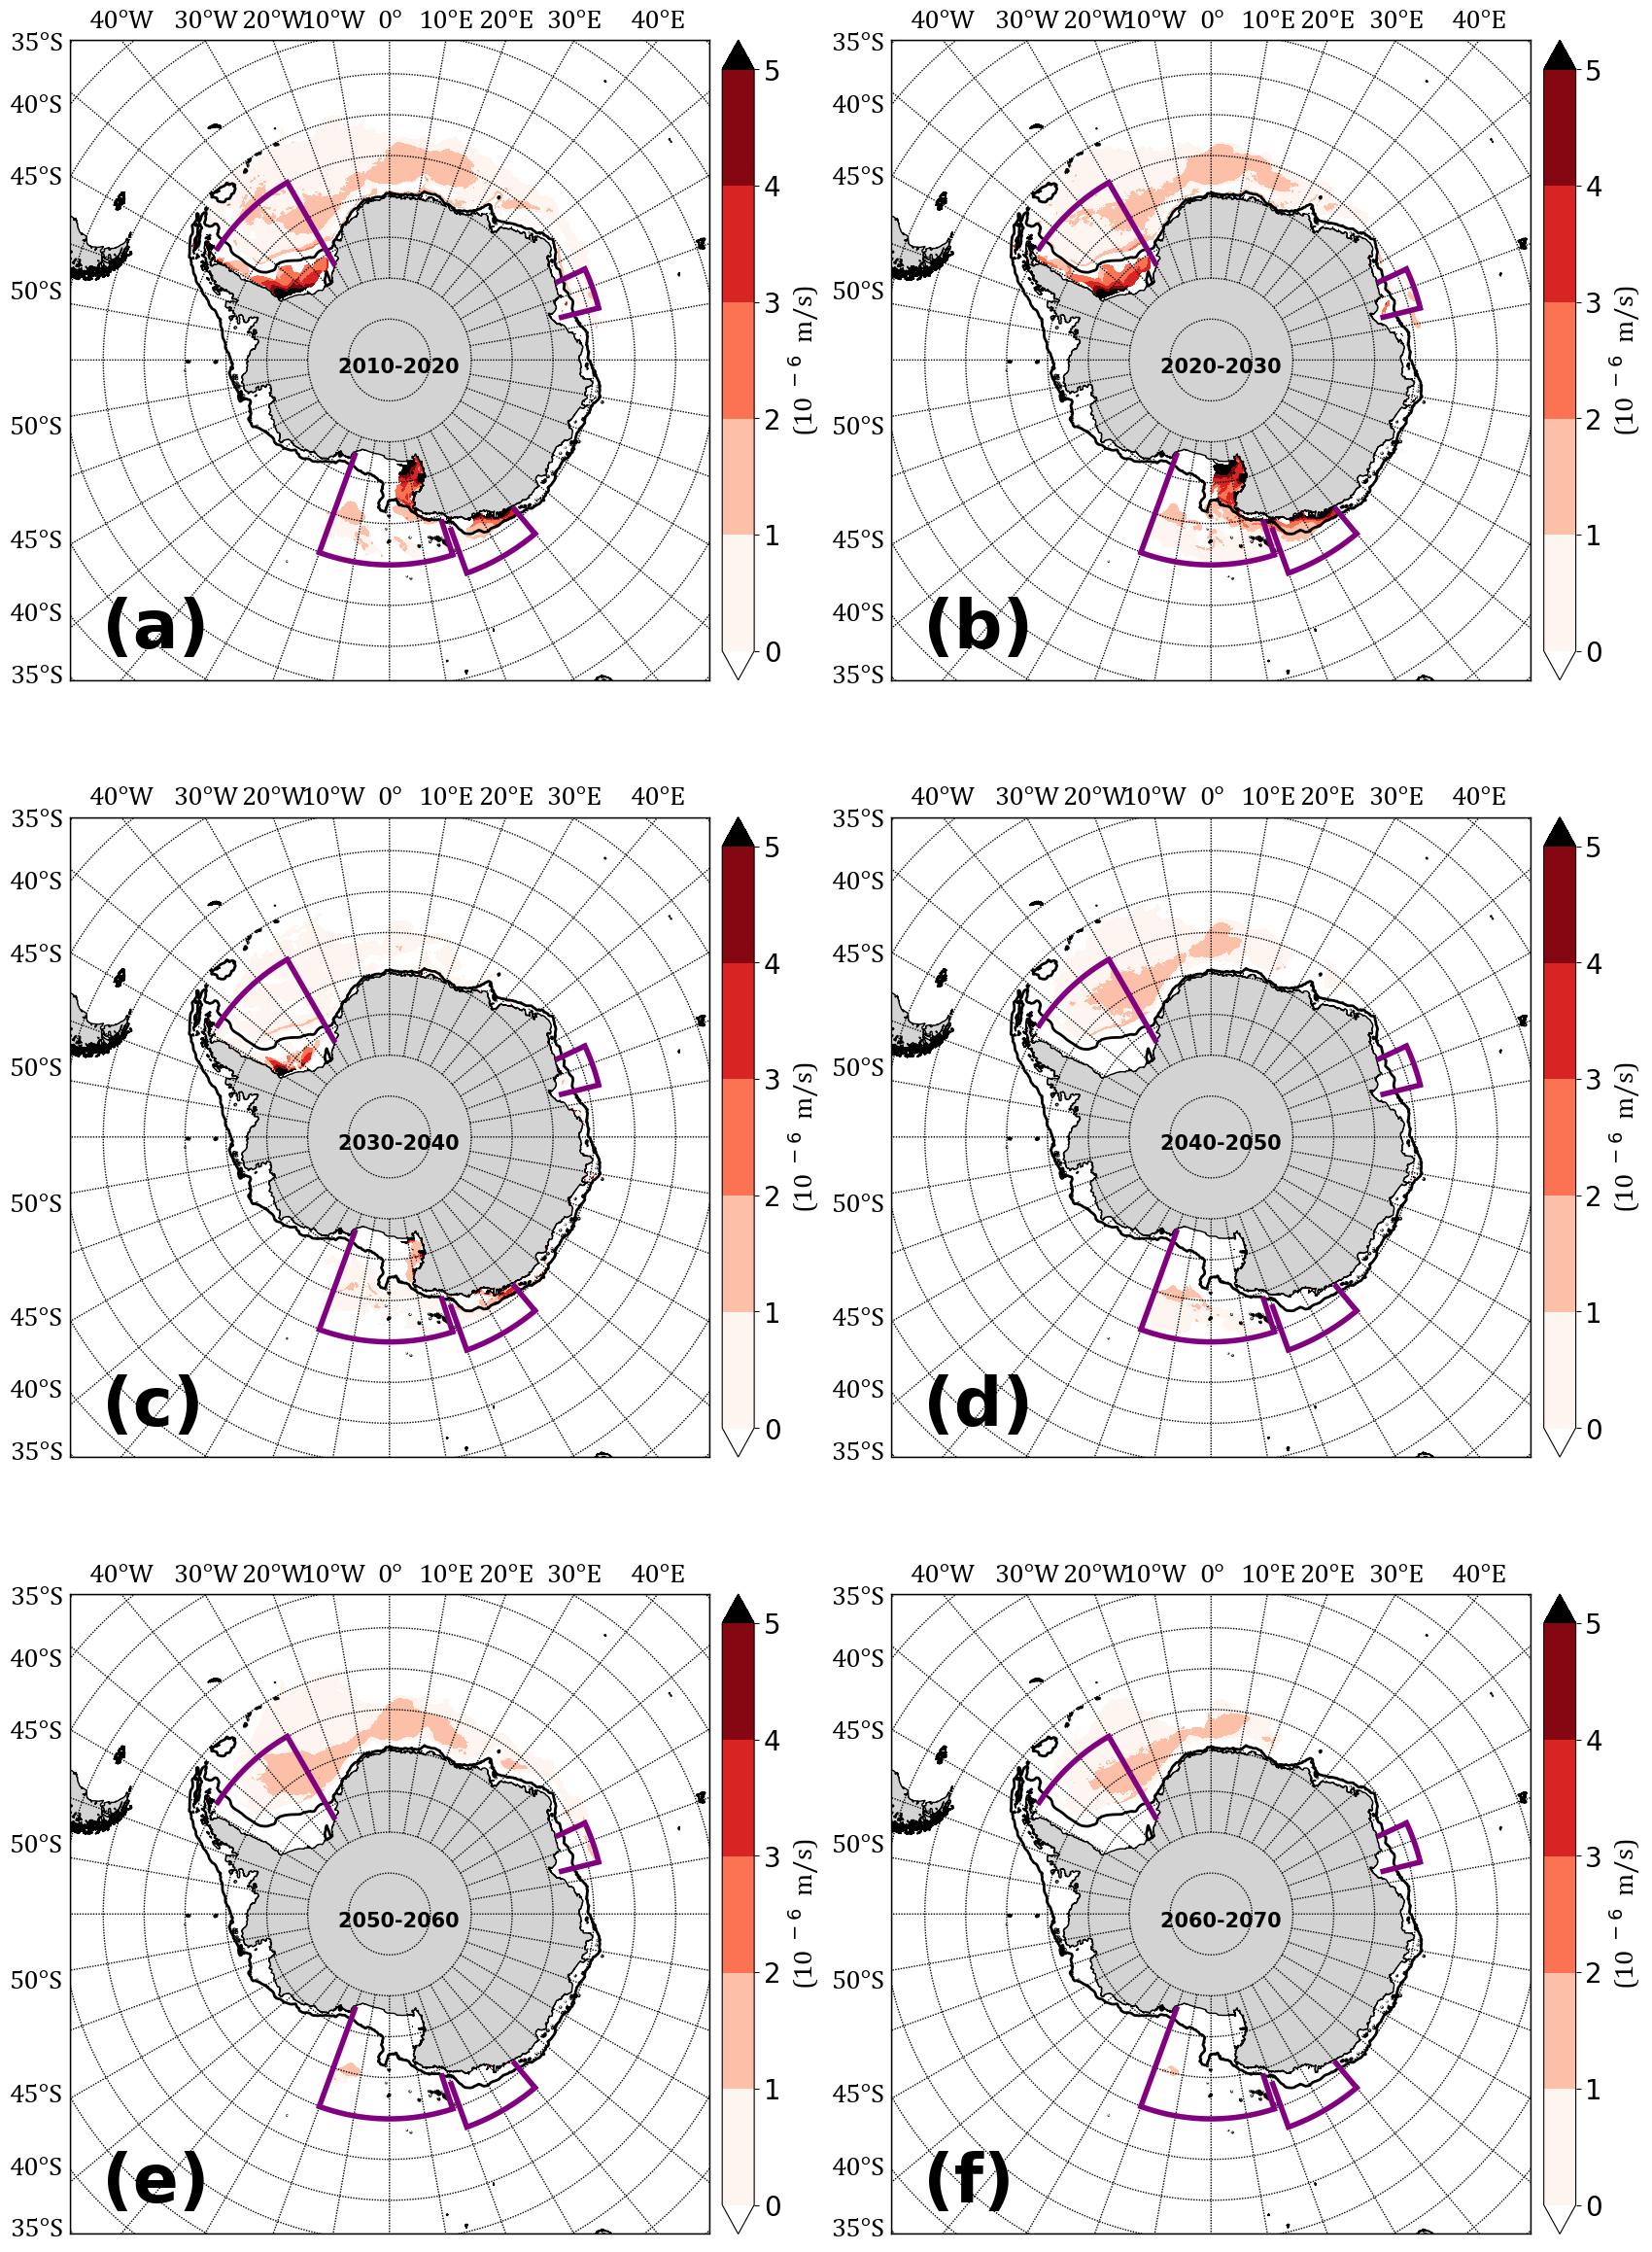

In [7]:
fig = plt.figure(figsize=(20,30), dpi=100)
#ax0 = fig.add_axes([0.1, 0.1, 0.8, 0.36],
                    #xticklabels=[])

ax = plt.subplot(3, 2, 6)
my_font = {'fontname':'Cambria', 'size':'20'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],WMT2060mea[:480,:]*1000000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('black')
CP.cmap.set_under('white')
CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=30,fmt='%1.1f')

cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=20) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^6$  m/s)', **my_font)
#plt.suptitle("TIME 0119-10",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.42, 0.48, '2060-2070 ', transform=ax.transAxes,size=15, weight='bold')
ax.text(0.05, 0.05, '(f)', transform=ax.transAxes,size=50, weight='bold')
################################
ax = plt.subplot(3, 2, 1)
my_font = {'fontname':'Cambria', 'size':'20'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],WMT2010mea[:480,:]*1000000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('black')
CP.cmap.set_under('white')
CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=30,fmt='%1.1f')

cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=20) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^6$  m/s)', **my_font)
#plt.suptitle("TIME 0119-10",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.42, 0.48, '2010-2020 ', transform=ax.transAxes,size=15, weight='bold')
ax.text(0.05, 0.05, '(a)', transform=ax.transAxes,size=50, weight='bold')
#############################################################################################
ax = plt.subplot(3, 2, 2)
my_font = {'fontname':'Cambria', 'size':'20'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],WMT2020mea[:480,:]*1000000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('black')
CP.cmap.set_under('white')
CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=30,fmt='%1.1f')

cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=20) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^6$  m/s)', **my_font)
#plt.suptitle("TIME 0119-10",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.42, 0.48, '2020-2030 ', transform=ax.transAxes,size=15, weight='bold')
ax.text(0.05, 0.05, '(b)', transform=ax.transAxes,size=50, weight='bold')
#############################################################################################
ax = plt.subplot(3, 2, 3)
my_font = {'fontname':'Cambria', 'size':'20'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],WMT2030mea[:480,:]*1000000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('black')
CP.cmap.set_under('white')
CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=30,fmt='%1.1f')

cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=20) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^6$  m/s)', **my_font)
#plt.suptitle("TIME 0119-10",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.42, 0.48, '2030-2040 ', transform=ax.transAxes,size=15, weight='bold')
ax.text(0.05, 0.05, '(c)', transform=ax.transAxes,size=50, weight='bold')
#############################################################################################
ax = plt.subplot(3, 2, 4)
my_font = {'fontname':'Cambria', 'size':'20'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],WMT2040mea[:480,:]*1000000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('black')
CP.cmap.set_under('white')
CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=30,fmt='%1.1f')

cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=20) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^6$  m/s)', **my_font)
#plt.suptitle("TIME 0119-10",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.42, 0.48, '2040-2050 ', transform=ax.transAxes,size=15, weight='bold')
ax.text(0.05, 0.05, '(d)', transform=ax.transAxes,size=50, weight='bold')
#############################################################################################
ax = plt.subplot(3, 2, 5)
my_font = {'fontname':'Cambria', 'size':'20'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],WMT2050mea[:480,:]*1000000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('black')
CP.cmap.set_under('white')
CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=30,fmt='%1.1f')

cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=20) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^6$  m/s)', **my_font)
#plt.suptitle("TIME 0119-10",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.42, 0.48, '2050-2060 ', transform=ax.transAxes,size=15, weight='bold')
ax.text(0.05, 0.05, '(e)', transform=ax.transAxes,size=50, weight='bold')
#############################################################################################
#############################################################################################
plt.savefig("WMTall444444.png",bbox_inches='tight')